# Analyzing Health Data using Support Vector Models

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from matplotlib.pyplot import subplots, cm
import sklearn.model_selection as skm
from ISLP import load_data, confusion_table
from sklearn.preprocessing import OneHotEncoder, LabelBinarizer, StandardScaler
scaler = StandardScaler()
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report

from sklearn.svm import SVC, LinearSVC
from ISLP.svm import plot as plot_svm
from sklearn.metrics import RocCurveDisplay, auc
roc_curve = RocCurveDisplay.from_estimator
#from sklearn.metrics import roc_curve, auc
import seaborn as sns
from itertools import combinations

## Data Cleaning

In [3]:
nihs = pd.read_csv("nhis_2022.csv")
nihs

,YEAR,SERIAL,STRATA,PSU,NHISHID,REGION,PERNUM,NHISPID,HHX,SAMPWEIGHT,...,TOMSAUCEMNO,SODAPNO,FRIESPNO,SPORDRMNO,FRTDRINKMNO,COFETEAMNO,POTATONO,PIZZANO,HRSLEEP,CVDSHT
0,2022,1,143,16,0002022H000001,4,1,0002022H00000110,H000001,8018.0,...,2,0,110,3,0,0,3,2,8,1
1,2022,2,106,53,0002022H000003,3,1,0002022H00000310,H000003,10117.0,...,1,0,1,0,0,1,1,1,6,2
2,2022,2,106,53,0002022H000003,3,2,0002022H00000320,H000003,7933.0,...,996,996,996,996,996,996,996,996,0,2
3,2022,3,134,13,0002022H000006,2,1,0002022H00000610,H000006,2681.0,...,1,1,1,0,2,0,1,1,6,2
4,2022,4,106,53,0002022H000007,3,1,0002022H00000710,H000007,10233.0,...,3,30,5,1,0,30,6,2,8,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35110,2022,28851,140,3,0002022H067791,1,2,0002022H06779120,H067791,7372.0,...,996,996,996,996,996,996,996,996,0,1
35111,2022,28852,106,2,0002022H067792,3,1,0002022H06779210,H067792,12676.0,...,1,2,1,2,0,2,4,2,7,2
35112,2022,28852,106,2,0002022H067792,3,2,0002022H06779220,H067792,3215.0,...,996,996,996,996,996,996,996,996,0,2
35113,2022,28853,147,74,0002022H067793,2,1,0002022H06779310,H067793,2430.0,...,3,2,2,0,0,0,2,2,5,2


In [4]:
# Removing Responses in Cancer Col which had no answer since I'm focusing on heart attacks
# It wouldn't make sense to keep non-responses

# There were 7464 responses of 'NIU'
# There were 28 responses of 'refused'
# There were 9 responses of 'don't know'
# This relates to 7501 / 35115 of the data, or 21%

target = 'HEARTATTEV'
nihs = nihs.drop(nihs[(nihs[target] == 0) | (nihs[target] > 6)].index)

# 1 is no heart attacks
# 2 is yes heart attacks
# Recode to 0 and 1 for better colormap behavior

nihs[target] = nihs[target].replace({2: 1, 1: 0})

print(nihs[target].value_counts())

HEARTATTEV
0    26591
1     1017
Name: count, dtype: int64


In [11]:
demographics = nihs[['YEAR', 'SERIAL', 'STRATA', 'PSU', 'NHISHID', 'REGION', 'PERNUM', 
                    'NHISPID', 'HHX', 'SAMPWEIGHT', 'ASTATFLG', 'CSTATFLG', 'AGE', 'SEX', 
                    'MARSTCUR', 'EDUC', 'HOURSWRK', 'POVERTY']]

health = nihs[['HEIGHT', 'WEIGHT', 'BMICALC', 'HINOTCOVE', 'CANCEREV', 'CHEARTDIEV', 
                'DIABETICEV', 'HEARTATTEV', 'STROKEV']]

lifestyle =  nihs[['DIABETICEV','ALCANYNO', 'ALCDAYSYR', 'CIGDAYMO', 'MOD10DMIN', 'VIG10DMIN', 'FRUTNO', 
                    'VEGENO', 'JUICEMNO', 'SALADSNO', 'BEANNO', 'SALSAMNO', 'SODAPNO', 
                    'FRIESPNO', 'SPORDRMNO', 'FRTDRINKMNO', 'COFETEAMNO', 'POTATONO', 
                    'PIZZANO', 'HRSLEEP', 'CVDSHT']]

## Examining Feature Interactions

In [156]:
# I looked at a number of subsets of the data, changing the non-answer cutoff as needed
all_features = nihs[['HHX', 'AGE','HEIGHT', 'WEIGHT', 'BMICALC', 'HINOTCOVE', 'CANCEREV', 'CHEARTDIEV', 
                'HEARTATTEV', 'STROKEV', 'DIABETICEV','ALCANYNO', 'ALCDAYSYR', 'CIGDAYMO',
                 'MOD10DMIN', 'VIG10DMIN', 'FRUTNO', 'VEGENO', 'JUICEMNO', 'SALADSNO', 'BEANNO', 
                 'SALSAMNO', 'SODAPNO', 'FRIESPNO', 'SPORDRMNO', 'FRTDRINKMNO', 'COFETEAMNO', 'POTATONO', 
                    'PIZZANO', 'HRSLEEP']]

# Drop non-numeric or identifier columns
non_features = ['YEAR', 'SERIAL', 'STRATA', 'PSU', 'NHISHID', 'NHISPID', 'HHX', 'PERNUM', 'SAMPWEIGHT']
all_features = all_features.drop(columns = non_features, errors = 'ignore')

In [158]:
all_features[target].value_counts()

HEARTATTEV
0    26591
1     1017
Name: count, dtype: int64

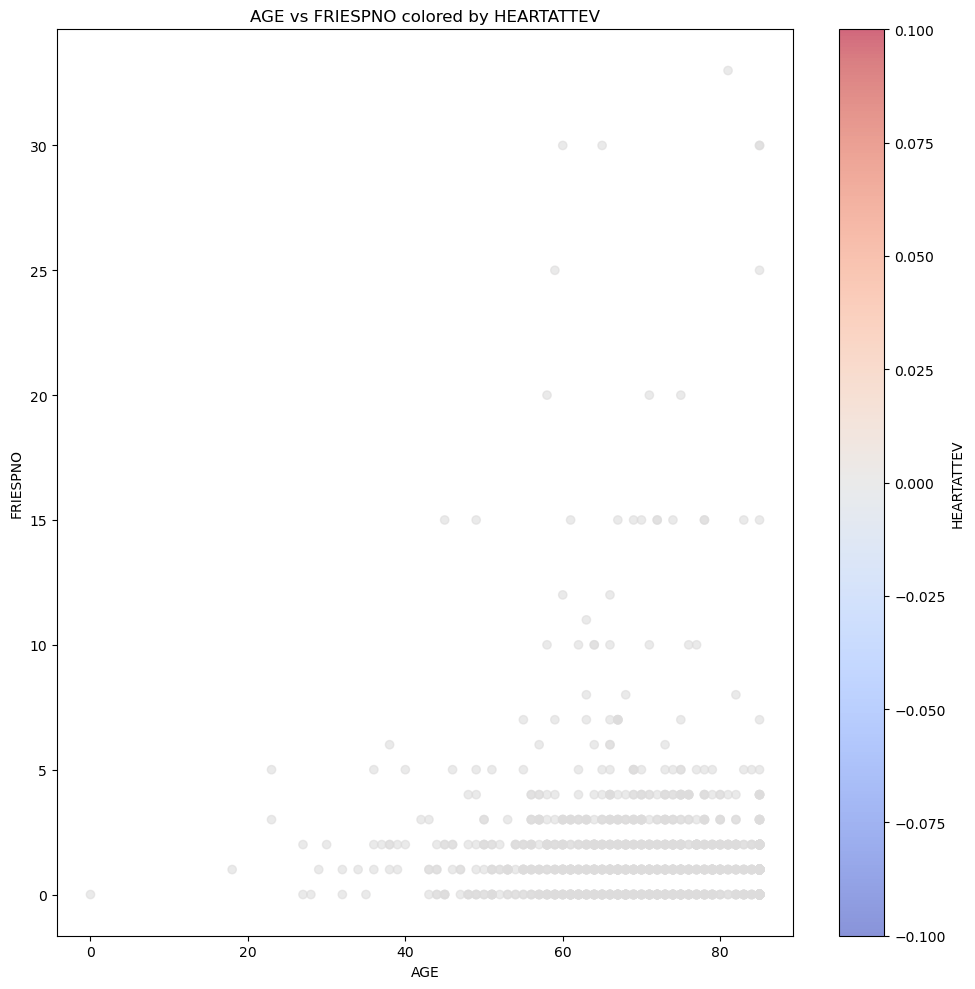

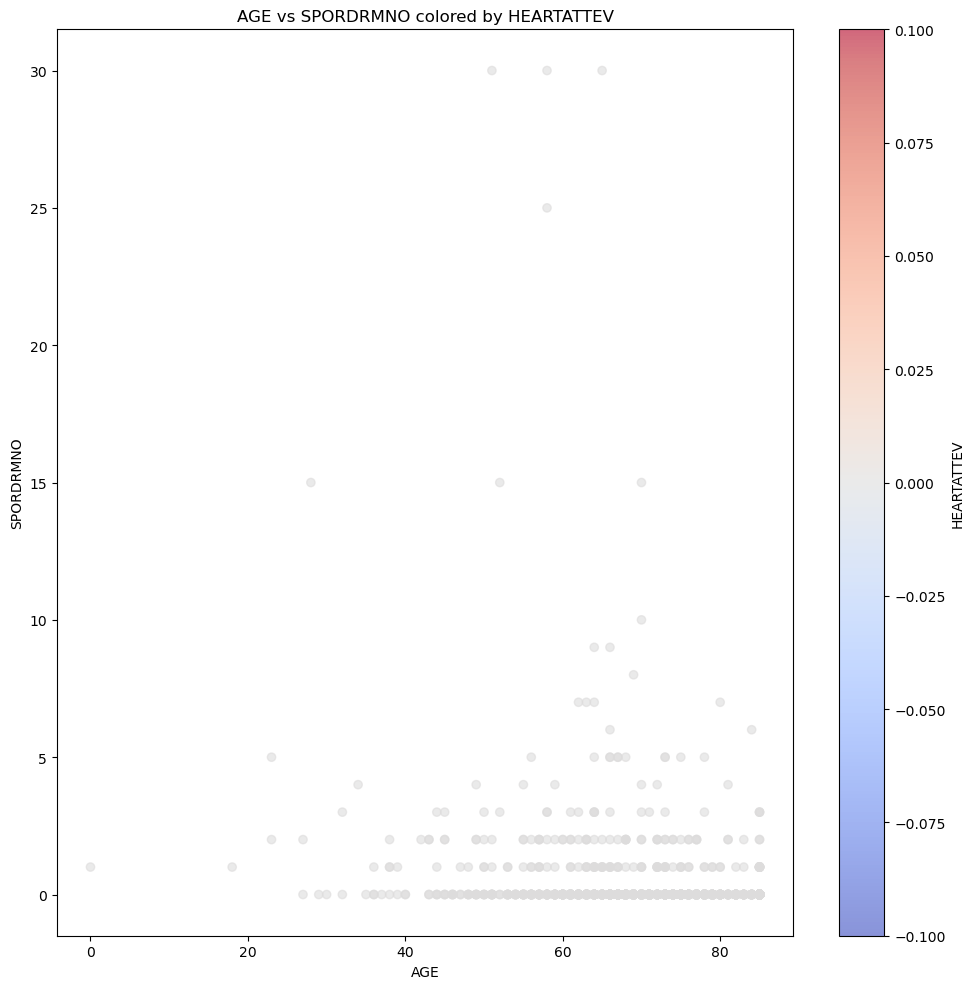

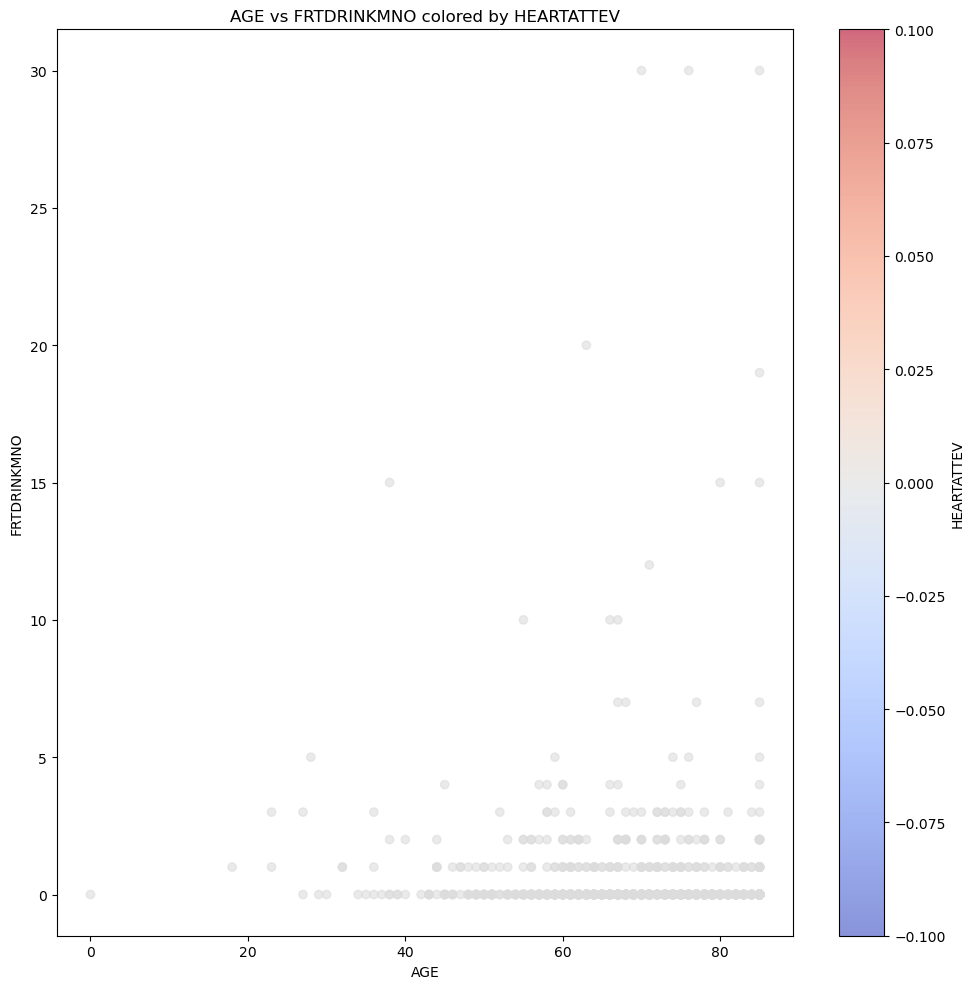

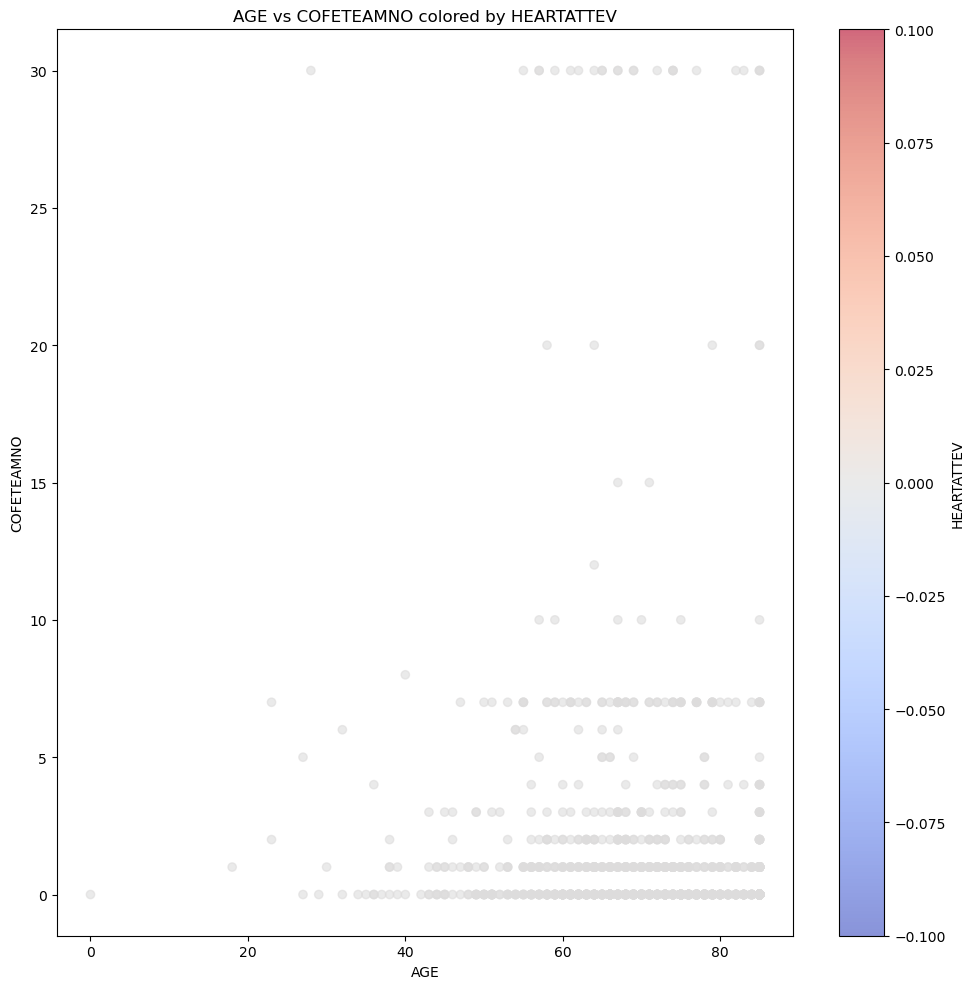

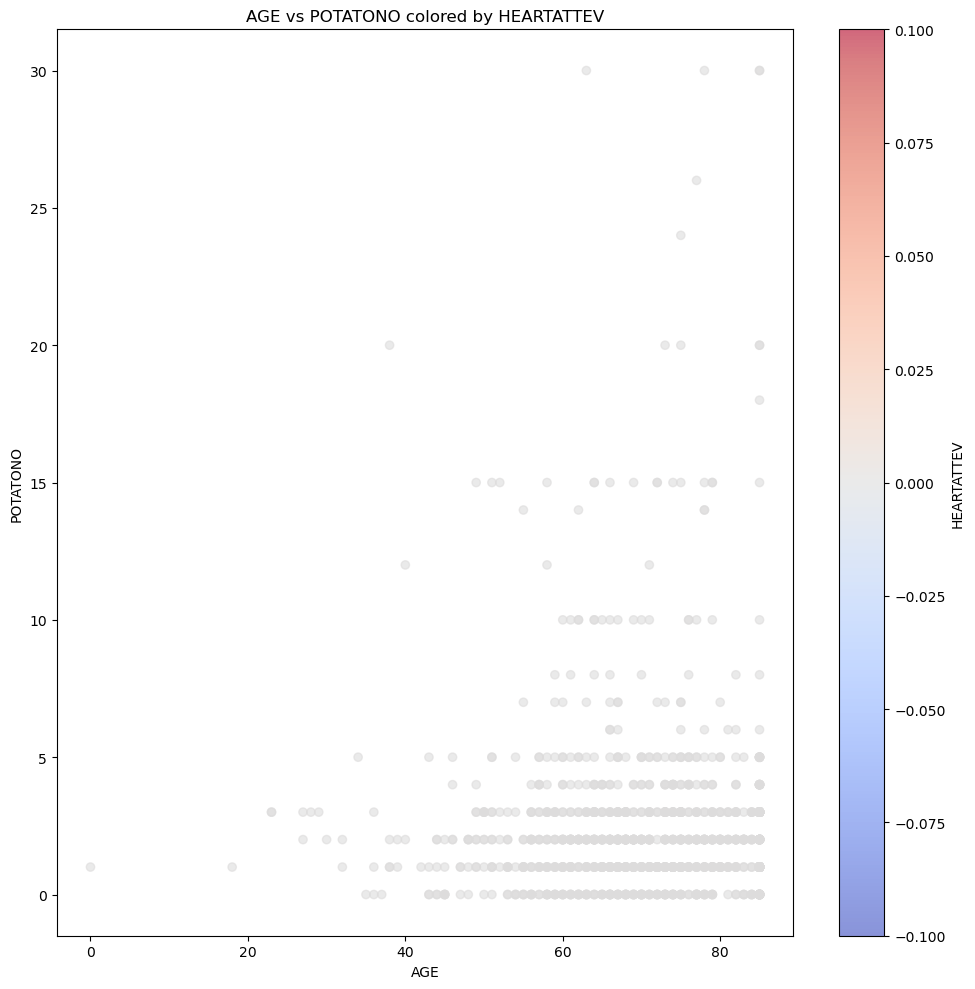

KeyboardInterrupt: 

In [130]:
# Non-answer cutoff point
all_features[all_features > 500] = 0

# Loop through feature combinations to plot
features = [col for col in all_features.columns if col != target]

for x, y in combinations(features, 2):
    plt.figure(figsize = (10, 10))
    plt.scatter(all_features[x], all_features[y], 
                c = all_features[target], cmap = 'coolwarm', alpha = 0.6)
    plt.xlabel(x)
    plt.ylabel(y)
    plt.title(f'{x} vs {y} colored by {target}')
    plt.colorbar(label = target)
    plt.tight_layout()
    plt.show()

## Support Vector Classifier - SVC - Linear

### Age vs Weight

#### Test/Train Split

In [351]:
age_weight = nihs[[target, 'AGE', 'WEIGHT']]

# Dropping values where age is over 130 and weight is over 400 to prevent 999 values
age_weight = age_weight.drop(age_weight[(age_weight['AGE'] >= 130) | (age_weight['WEIGHT'] >= 400)].index)
age_weight = age_weight.reset_index(drop = True)
train_data_aw, test_data_aw = train_test_split(age_weight, train_size = 0.8, random_state = 42)

X_train_aw = train_data_aw.drop(columns = [target])
y_train_aw = train_data_aw[target]
X_test_aw = test_data_aw.drop(columns = [target])
y_test_aw = test_data_aw[target]

X_train_scaled_aw = scaler.fit_transform(X_train_aw)
X_test_scaled_aw = scaler.transform(X_test_aw)

In [353]:
age_weight

,HEARTATTEV,AGE,WEIGHT
0,0,61,260
1,0,43,190
2,0,68,200
3,0,73,172
4,0,73,190
...,...,...,...
25242,0,84,113
25243,0,45,225
25244,0,47,225
25245,0,37,185


In [355]:
print(y_train_aw.value_counts())
print(y_test_aw.value_counts())

HEARTATTEV
0    19439
1      758
Name: count, dtype: int64
HEARTATTEV
0    4880
1     170
Name: count, dtype: int64


In [357]:
# Creating the initial linear model
svm_linear_aw = SVC(C = 25, kernel = 'linear', class_weight = 'balanced')
svm_linear_aw.fit(X_train_scaled_aw, y_train_aw)

SVC(C=25, class_weight='balanced', kernel='linear')

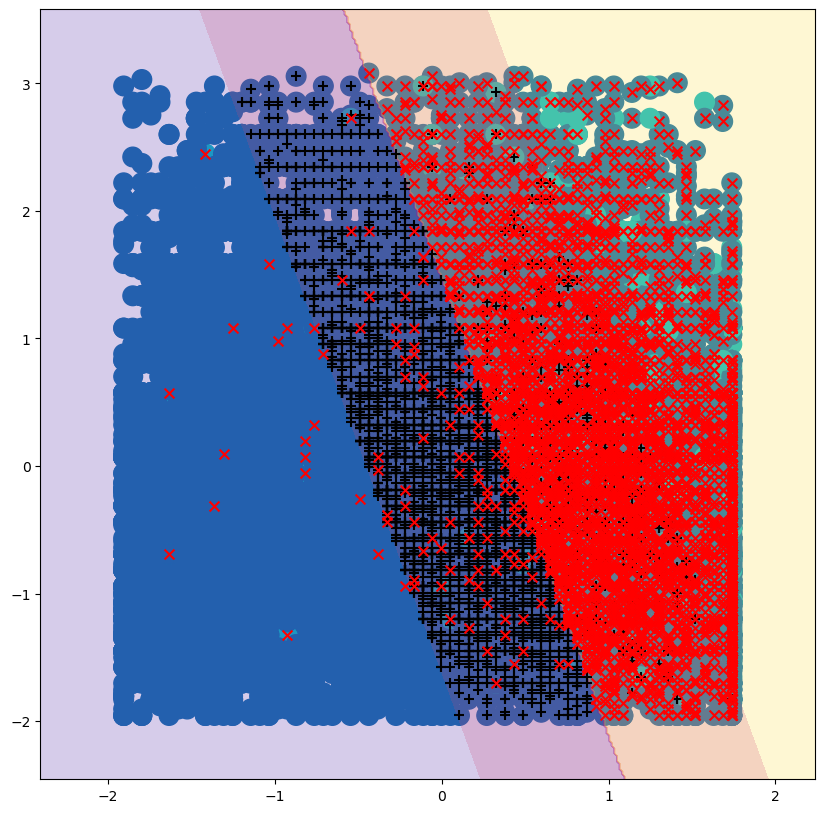

In [358]:
# Plotting
fig, ax = subplots(figsize = (10, 10))
plot_svm(X_train_scaled_aw,
         y_train_aw.to_numpy(),
         svm_linear_aw,
         ax = ax)

This does show that we're getting predictions for heart attack which means the class size differences are being taken into account by the model

In [360]:
y_test_hat_aw = svm_linear_aw.predict(X_test_scaled_aw)
confusion_table(y_test_hat_aw, y_test_aw)

Truth,0,1
Predicted,,
0,2958,35
1,1922,135


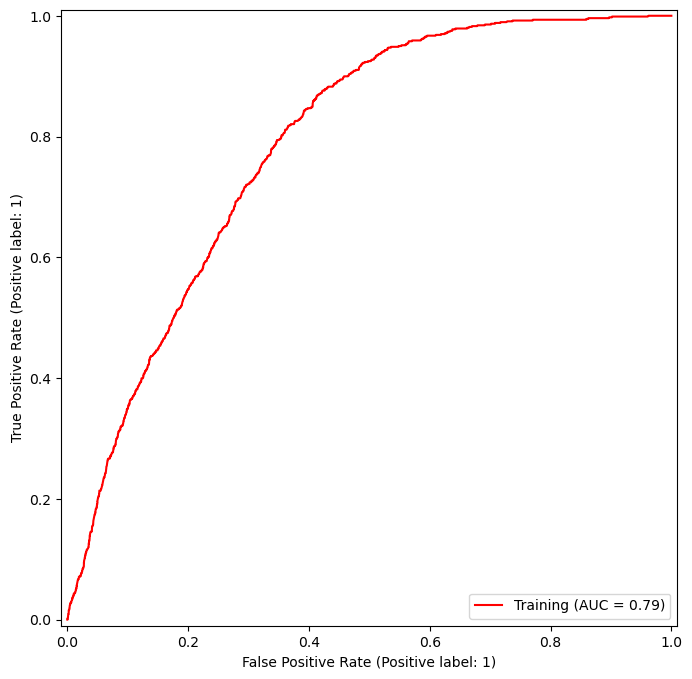

In [361]:
fig, ax = subplots(figsize = (8, 8))
roc_curve(svm_linear_aw,
          X_train_scaled_aw,
          y_train_aw,
          name = 'Training',
          color = 'r',
          ax = ax);

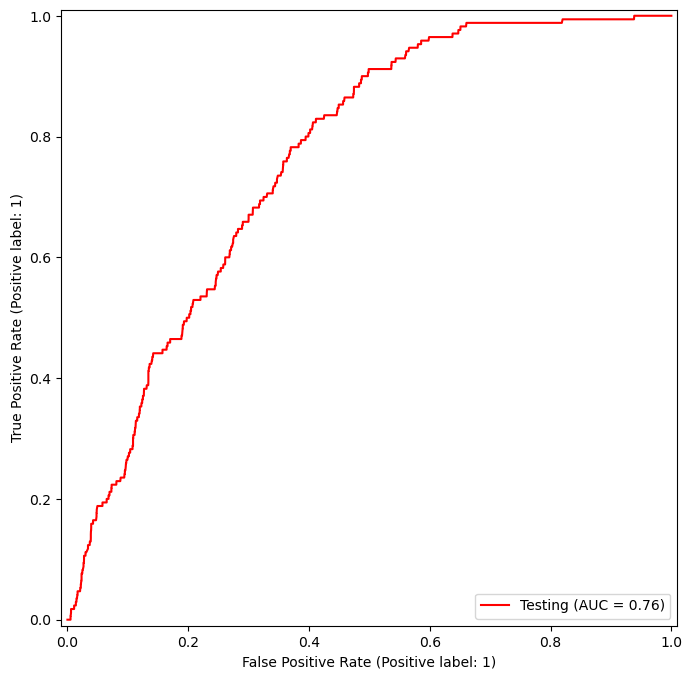

In [362]:
fig, ax = subplots(figsize = (8, 8))
roc_curve(svm_linear_aw,
          X_test_scaled_aw,
          y_test_aw,
          name = 'Testing',
          color = 'r',
          ax = ax);

In [363]:
# Tuning

kfold = skm.KFold(5, random_state = 5, shuffle = True)
grid = skm.GridSearchCV(svm_linear_aw,
                        {'C':[ 0.00001, 0.0001, 0.001, 0.01, 0.1, 1, 10, 50]},
                        refit = True,
                        cv = kfold,
                        scoring = 'balanced_accuracy')
grid.fit(X_test_scaled_aw, y_test_aw)

print(grid.best_params_)
print(grid.cv_results_[('mean_test_score')])

{'C': 1}
[0.5        0.5        0.70770035 0.70404436 0.70771887 0.70812443
 0.7079218  0.70802145]


In [364]:
# Reruning with tuned parameters
svm_linear_aw2 = SVC(C = 1, kernel = 'linear', class_weight = 'balanced')
svm_linear_aw2.fit(X_train_scaled_aw, y_train_aw)

SVC(C=1, class_weight='balanced', kernel='linear')

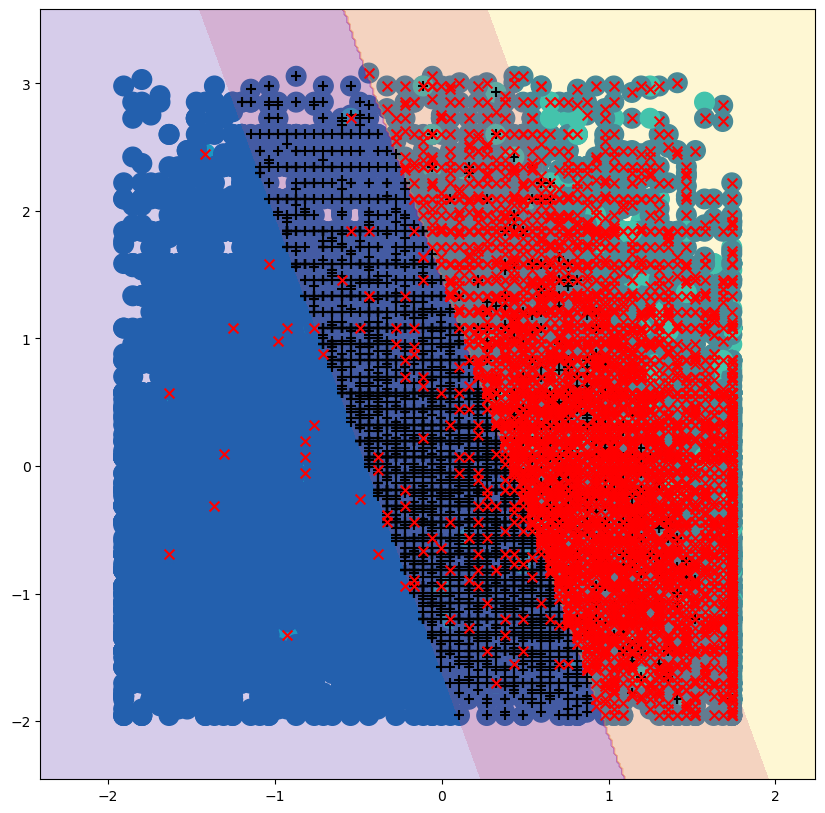

In [365]:
# New plot
fig, ax = subplots(figsize = (10, 10))
plot_svm(X_train_scaled_aw,
         y_train_aw.to_numpy(),
         svm_linear_aw2,
         ax=ax)

In [366]:
y_test_hat_aw2 = svm_linear_aw2.predict(X_test_scaled_aw)
confusion_table(y_test_hat_aw2, y_test_aw)

Truth,0,1
Predicted,,
0,2958,35
1,1922,135


In [367]:
(2958+135) / (2958+135+35+1922)

0.6124752475247525

Looks like there wasn't a better split of the data since the confusion matrix is the same as before and so are the ROC AUC values for training and testing

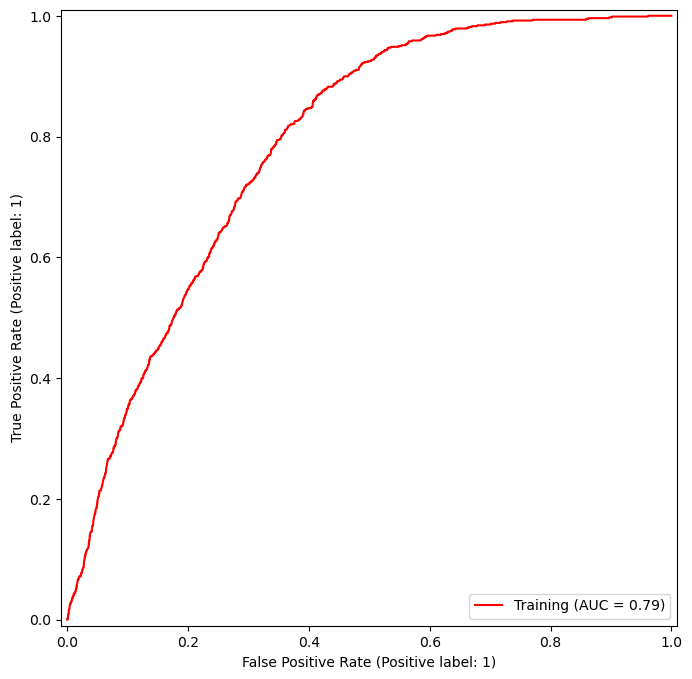

In [369]:
fig, ax = subplots(figsize = (8, 8))
roc_curve(svm_linear_aw2,
          X_train_scaled_aw,
          y_train_aw,
          name = 'Training',
          color = 'r',
          ax = ax);

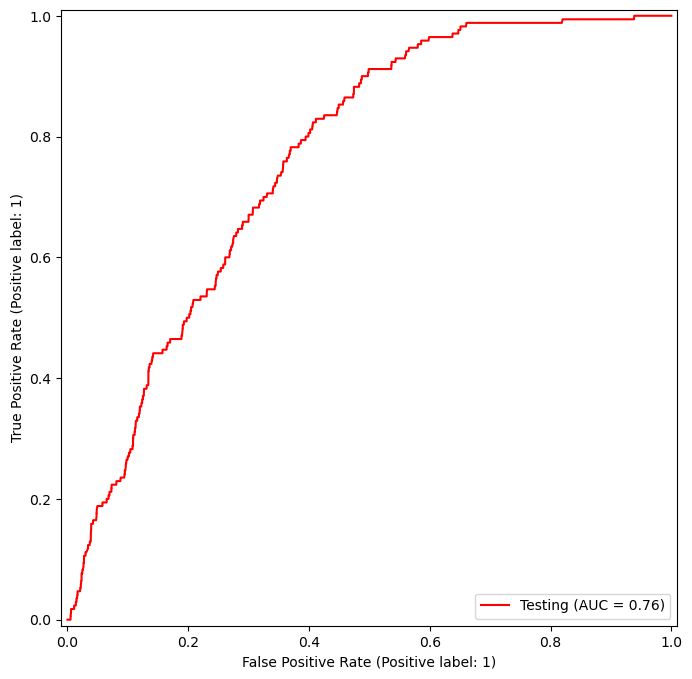

In [370]:
fig, ax = subplots(figsize = (8, 8))
roc_curve(svm_linear_aw2,
          X_test_scaled_aw,
          y_test_aw,
          name = 'Testing',
          color = 'r',
          ax = ax);

In [371]:
y_pred = svm_linear_aw2.predict(X_test_scaled_aw)
print(classification_report(y_test_aw, y_pred, 
                           target_names = ['No Heart Attack', 'Heart Attack']))

                 precision    recall  f1-score   support

No Heart Attack       0.99      0.61      0.75      4880
   Heart Attack       0.07      0.79      0.12       170

       accuracy                           0.61      5050
      macro avg       0.53      0.70      0.44      5050
   weighted avg       0.96      0.61      0.73      5050



Heart attacks aren't being predicted super well according to the precision, but the recall indicates that a 80% of them are being accurately predicted. It's not an amazing model but it's still got some predictive power

### Age vs Cigarette Use

In [217]:
age_cig = nihs[[target, 'AGE', 'CIGDAYMO']]
age_cig = age_cig.drop(age_cig[(age_cig['AGE'] >= 130)].index)
age_cig.loc[age_cig['CIGDAYMO'] >= 32, 'CIGDAYMO'] = 0
age_cig.reset_index(drop = True)


train_data_ac, test_data_ac = train_test_split(age_cig, train_size = 0.8, random_state = 42)
age_cig = age_cig.reset_index(drop = True)

X_train_ac = train_data_ac.drop(columns = [target])
y_train_ac = train_data_ac[target]
X_test_ac = test_data_ac.drop(columns = [target])
y_test_ac = test_data_ac[target]

X_train_scaled_ac = scaler.fit_transform(X_train_ac)
X_test_scaled_ac = scaler.transform(X_test_ac)

In [219]:
age_cig

,HEARTATTEV,AGE,CIGDAYMO
0,0,61,0
1,0,43,0
2,0,68,0
3,0,73,0
4,0,73,0
...,...,...,...
27541,0,45,0
27542,0,47,0
27543,0,37,0
27544,0,18,0


In [221]:
svm_linear_ac = SVC(C = 5, kernel = 'linear', class_weight = 'balanced')
svm_linear_ac.fit(X_train_scaled_ac, y_train_ac)

SVC(C=5, class_weight='balanced', kernel='linear')

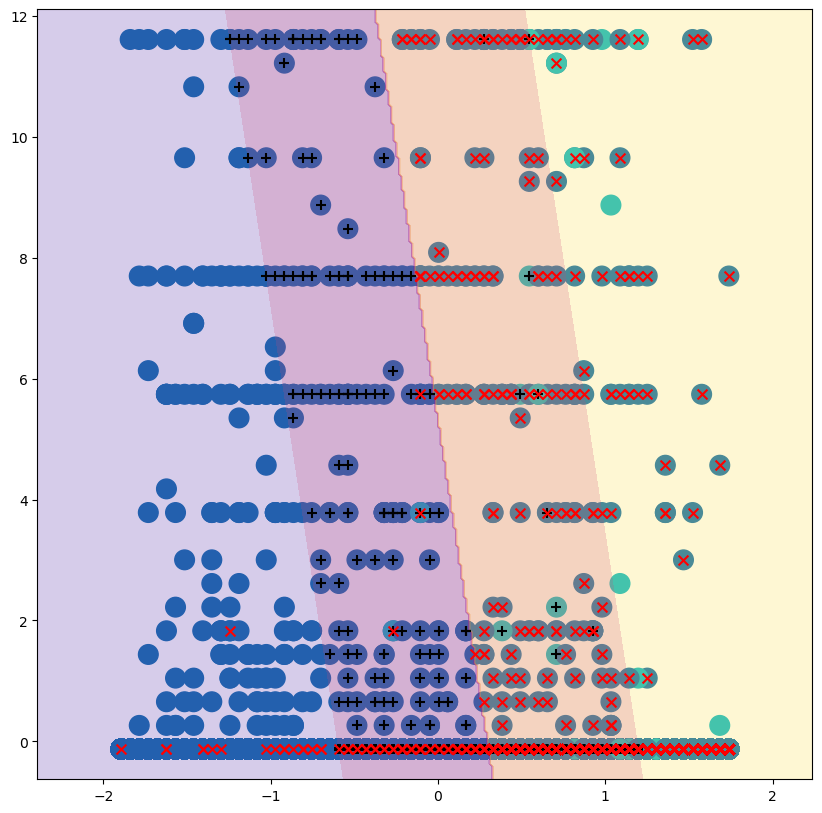

In [223]:
fig, ax = subplots(figsize = (10, 10))
plot_svm(X_train_scaled_ac,
         y_train_ac.to_numpy(),
         svm_linear_ac,
         ax = ax)

In [226]:
y_test_hat_ac = svm_linear_ac.predict(X_test_scaled_ac)
confusion_table(y_test_hat_ac, y_test_ac)

Truth,0,1
Predicted,,
0,3082,37
1,2222,169


In [310]:
30/(52)

0.5769230769230769

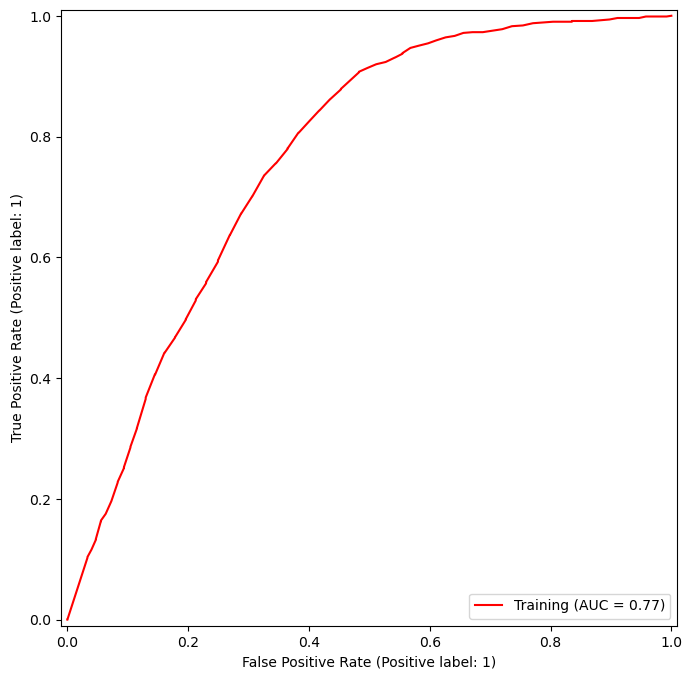

In [229]:
fig, ax = subplots(figsize = (8, 8))
roc_curve(svm_linear_ac,
          X_train_scaled_ac,
          y_train_ac,
          name = 'Training',
          color = 'r',
          ax = ax);

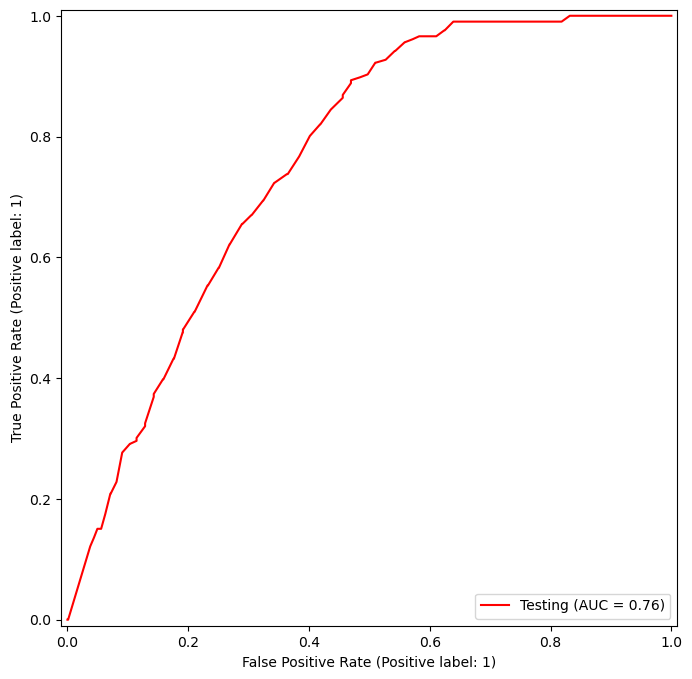

In [231]:
fig, ax = subplots(figsize = (8, 8))
roc_curve(svm_linear_ac,
          X_test_scaled_ac,
          y_test_ac,
          name = 'Testing',
          color = 'r',
          ax = ax);

In [225]:
# Tuning
kfold = skm.KFold(5, random_state = 5, shuffle = True)
grid = skm.GridSearchCV(svm_linear_ac,
                        {'C':[10, 1, 0.01, 0.1, 0.001, 0.0001]},
                        refit = True,
                        cv = kfold,
                        scoring = 'accuracy')
grid.fit(X_test_ac, y_test_ac)
print(grid.best_params_)
print(grid.cv_results_[('mean_test_score')])

{'C': 1}
[0.58439201 0.5876588  0.58439201 0.5876588  0.58021779 0.58021779]


In [233]:
# New model with adjusted params
svm_linear_ac2 = SVC(C = 1, kernel = 'linear', class_weight = 'balanced')
svm_linear_ac2.fit(X_train_scaled_ac, y_train_ac)

SVC(C=1, class_weight='balanced', kernel='linear')

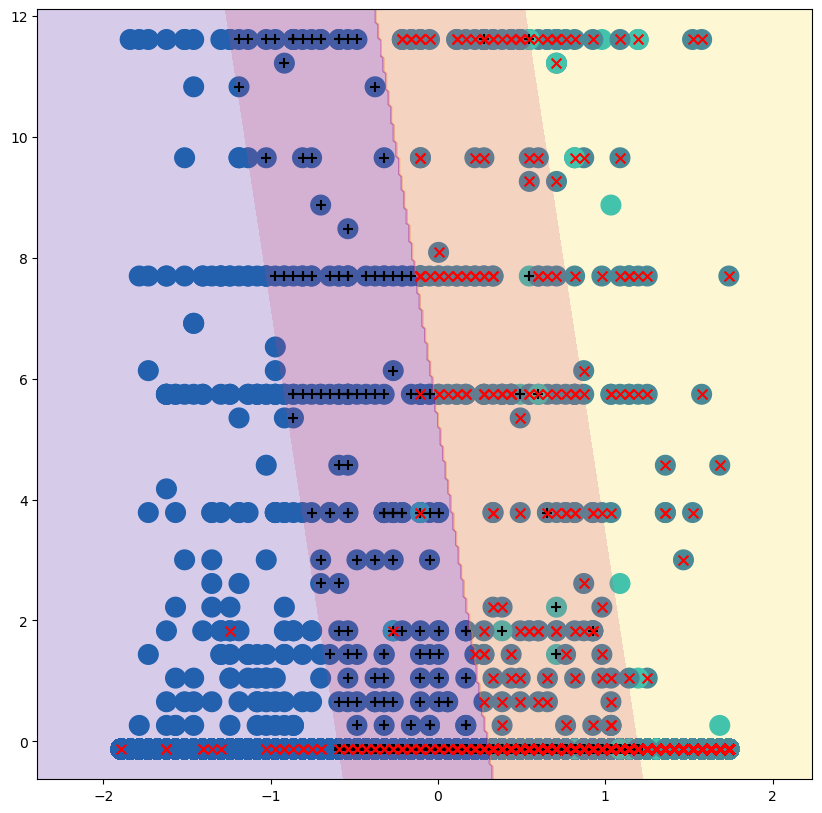

In [234]:
fig, ax = subplots(figsize = (10, 10))
plot_svm(X_train_scaled_ac,
         y_train_ac.to_numpy(),
         svm_linear_ac2,
         ax = ax)

C:\Users\Savannah Truluck\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but SVC was fitted without feature names
  warnings.warn(


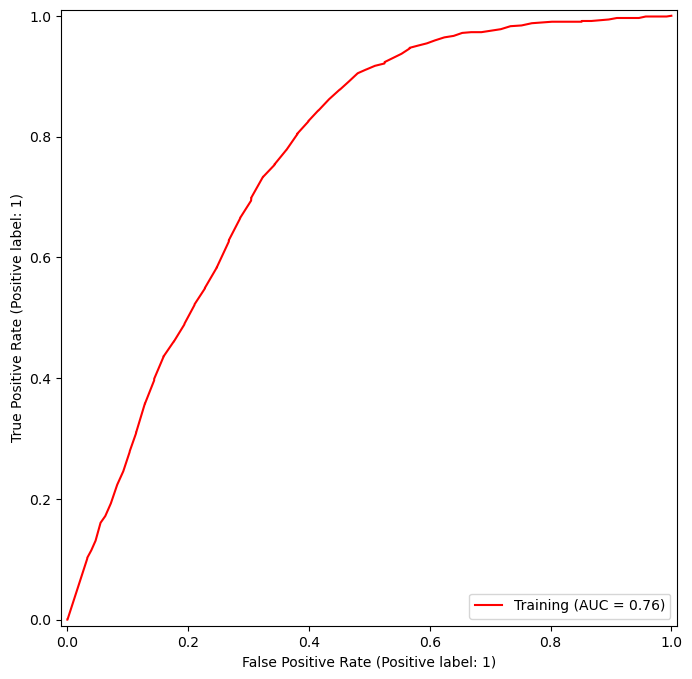

In [236]:
fig, ax = subplots(figsize = (8, 8))
roc_curve(svm_linear_ac2,
          X_train_ac,
          y_train_ac,
          name = 'Training',
          color = 'r',
          ax = ax);

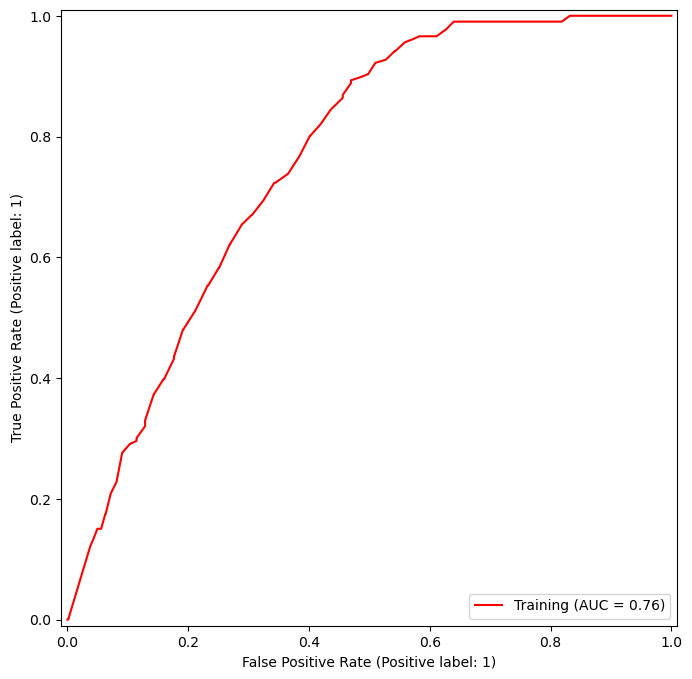

In [237]:
fig, ax = subplots(figsize = (8, 8))
roc_curve(svm_linear_ac2,
          X_test_scaled_ac,
          y_test_ac,
          name = 'Training',
          color = 'r',
          ax = ax);

In [238]:
y_test_hat_ac2 = svm_linear_ac2.predict(X_test_scaled_ac)
confusion_table(y_test_hat_ac2, y_test_ac)

Truth,0,1
Predicted,,
0,3082,37
1,2222,169


So, same results as with the age vs weight model where the first linear fit had the same confusion matrix as the cross validated model. For age vs cigarette use the recall was 58% for no heart attack and 82% for heart attack. Unfortunately, there's also a lot of false positives with this model despite it having a good AUC test score of 76

In [239]:
y_pred = svm_linear_ac2.predict(X_test_scaled_ac)
print(classification_report(y_test_ac, y_pred, 
                           target_names = ['No Heart Attack', 'Heart Attack']))

                 precision    recall  f1-score   support

No Heart Attack       0.99      0.58      0.73      5304
   Heart Attack       0.07      0.82      0.13       206

       accuracy                           0.59      5510
      macro avg       0.53      0.70      0.43      5510
   weighted avg       0.95      0.59      0.71      5510



## SVM - Radial

### Age vs Weight

In [284]:
age_weight_poly = nihs[[target, 'AGE', 'WEIGHT', 'CIGDAYMO', 'SODAPNO']]
age_weight_poly = age_weight_poly.drop(age_weight_poly[(age_weight_poly['AGE'] >= 130) | 
                             (age_weight_poly['WEIGHT'] >= 400) |
                             (age_weight_poly['SODAPNO'] >= 35)].index)

age_weight_poly.loc[age_weight_poly['CIGDAYMO'] >= 32, 'CIGDAYMO'] = 0
age_weight_poly.reset_index(drop = True)


train_data_awp, test_data_awp = train_test_split(age_weight_poly, train_size = 0.8, random_state = 42)

X_train_awp = train_data_awp.drop(columns = [target])
y_train_awp = train_data_awp[target]
X_test_awp = test_data_awp.drop(columns = [target])
y_test_awp = test_data_awp[target]

X_train_scaled_awp = scaler.fit_transform(X_train_awp)
X_test_scaled_awp = scaler.transform(X_test_awp)

In [286]:
age_weight_poly

,HEARTATTEV,AGE,WEIGHT,CIGDAYMO,SODAPNO
0,0,61,260,0,0
1,0,43,190,0,0
3,0,68,200,0,1
4,0,73,172,0,30
6,0,73,190,0,5
...,...,...,...,...,...
35106,0,84,113,0,0
35107,0,45,225,0,0
35108,0,47,225,0,0
35109,0,37,185,0,4


In [288]:
svm_rbf_awp = SVC(C = 1, kernel = 'rbf', class_weight = 'balanced', gamma = 1)
svm_rbf_awp.fit(X_train_scaled_awp, y_train_awp)

SVC(C=1, class_weight='balanced', gamma=1)

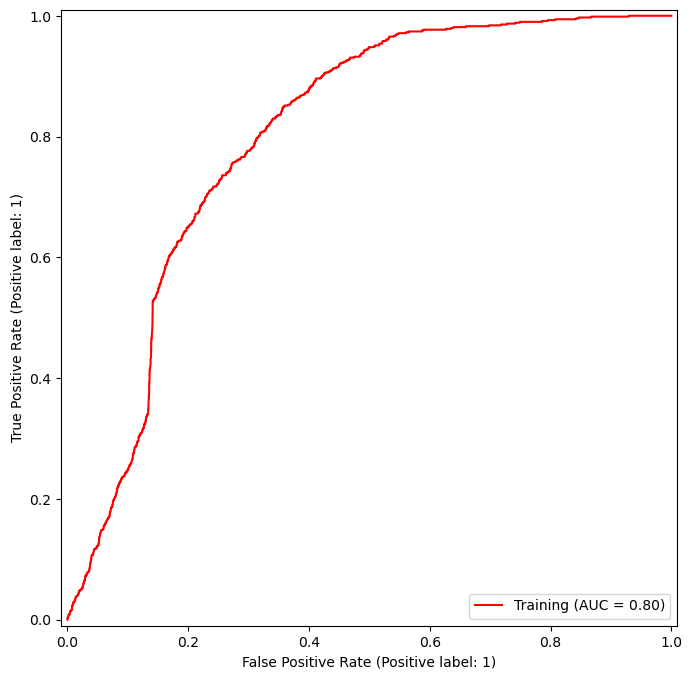

In [289]:
fig, ax = subplots(figsize = (8, 8))
roc_curve(svm_rbf_awp,
          X_train_scaled_awp,
          y_train_awp,
          name = 'Training',
          color = 'r',
          ax = ax);

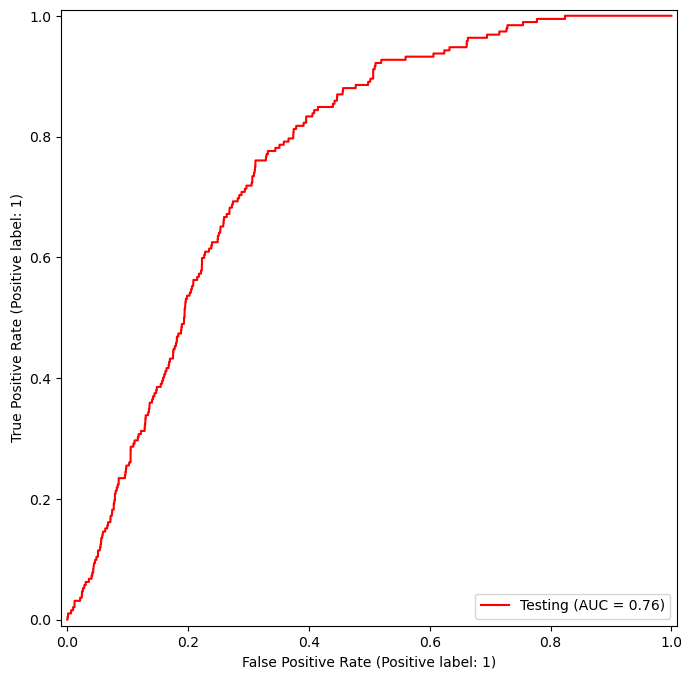

In [290]:
fig, ax = subplots(figsize = (8, 8))
roc_curve(svm_rbf_awp,
          X_test_scaled_awp,
          y_test_awp,
          name = 'Testing',
          color = 'r',
          ax = ax);

In [296]:
y_hat_test_awp = svm_rbf_awp.predict(X_test_awp)
confusion_table(y_hat_test_awp, y_test_awp)

C:\Users\Savannah Truluck\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but SVC was fitted without feature names
  warnings.warn(


Truth,0,1
Predicted,,
0,4668,192
1,0,0


In [298]:
kfold = skm.KFold(2, random_state = 0,
                  shuffle = True)
grid = skm.GridSearchCV(svm_rbf_awp,
                        {'C':[5, 10],
                         'gamma': [2, 3]},
                        refit = True,
                        cv = kfold,
                        scoring = 'balanced_accuracy');
grid.fit(X_train_awp, y_train_awp)
print(grid.best_params_)
print(grid.cv_results_[('mean_test_score')])

{'C': 5, 'gamma': 2}
[0.51437633 0.51437633 0.51437633 0.51437633]


In [317]:
svm_rbf_awp = SVC(C = 5, kernel = 'rbf', class_weight = 'balanced', gamma = 2)
svm_rbf_awp.fit(X_train_scaled_awp, y_train_awp)

SVC(C=5, class_weight='balanced', gamma=2)

In [319]:
y_hat_test_awp = svm_rbf_awp.predict(X_test_awp)
confusion_table(y_hat_test_awp, y_test_awp)

C:\Users\Savannah Truluck\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but SVC was fitted without feature names
  warnings.warn(


Truth,0,1
Predicted,,
0,4668,192
1,0,0


In [325]:
4668/(4668+192)

0.9604938271604938

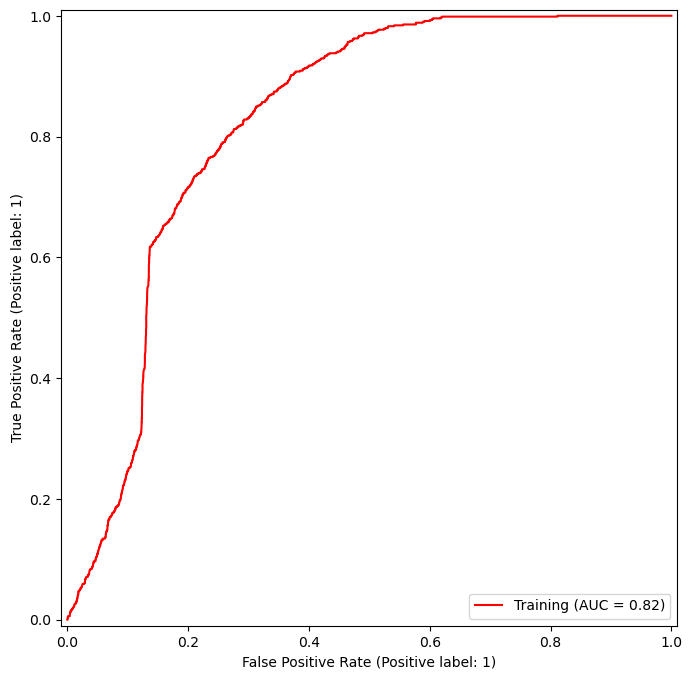

In [320]:
fig, ax = subplots(figsize = (8, 8))
roc_curve(svm_rbf_awp,
          X_train_scaled_awp,
          y_train_awp,
          name = 'Training',
          color = 'r',
          ax = ax);

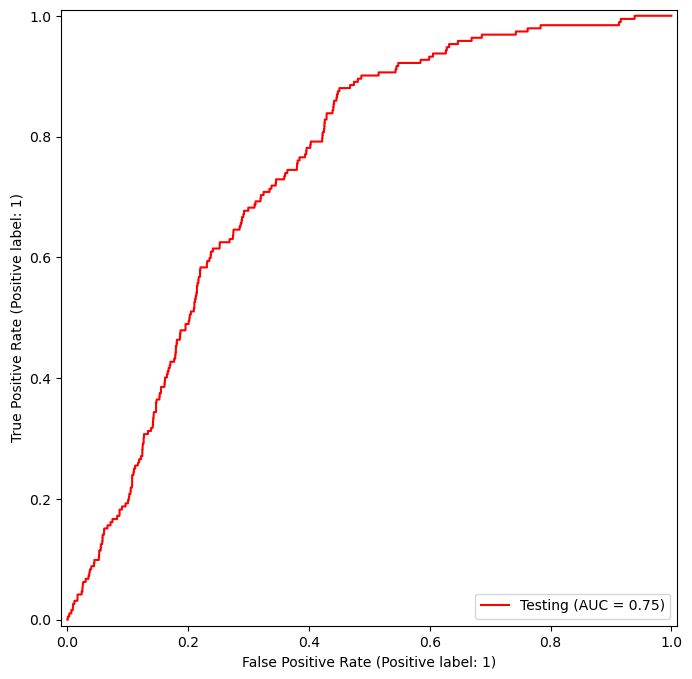

In [321]:
fig, ax = subplots(figsize = (8, 8))
roc_curve(svm_rbf_awp,
          X_test_scaled_awp,
          y_test_awp,
          name = 'Testing',
          color = 'r',
          ax = ax);

In [333]:
y_pred = svm_rbf_awp.predict(X_test_scaled_awp)
print(classification_report(y_test_awp, y_pred, 
                           target_names = ['No Heart Attack', 'Heart Attack']))

                 precision    recall  f1-score   support

No Heart Attack       0.98      0.65      0.78      4668
   Heart Attack       0.08      0.73      0.14       192

       accuracy                           0.65      4860
      macro avg       0.53      0.69      0.46      4860
   weighted avg       0.95      0.65      0.76      4860



## SVM - Polynomial Kernels

In [8]:
bmi_pop = nihs[[target, 'SODAPNO', 'AGE', 'WEIGHT', 'CIGDAYMO',]]
bmi_pop = bmi_pop.drop(bmi_pop[(bmi_pop['AGE'] >= 130) | (bmi_pop['WEIGHT'] >= 400) |
                         (bmi_pop ['SODAPNO'] >= 32)].index)
bmi_pop.loc[bmi_pop['CIGDAYMO'] >= 32, 'CIGDAYMO'] = 0
bmi_pop = bmi_pop.reset_index(drop = True)

train_data_bp, test_data_bp = train_test_split(bmi_pop, train_size = 0.8, random_state = 42)

X_train_bp = train_data_bp.drop(columns = [target])
y_train_bp = train_data_bp[target]
X_test_bp = test_data_bp.drop(columns = [target])
y_test_bp = test_data_bp[target]

X_train_scaled_bp = scaler.fit_transform(X_train_bp)
X_test_scaled_bp = scaler.transform(X_test_bp)

In [10]:
bmi_pop

,HEARTATTEV,SODAPNO,AGE,WEIGHT,CIGDAYMO
0,0,0,61,260,0
1,0,0,43,190,0
2,0,1,68,200,0
3,0,30,73,172,0
4,0,5,73,190,0
...,...,...,...,...,...
24295,0,0,84,113,0
24296,0,0,45,225,0
24297,0,0,47,225,0
24298,0,4,37,185,0


KeyError: '[17, 29, 30, 31, 34, 35, 44, 46, 52, 54, 57, 59, 69, 75, 101, 102, 103, 115, 119, 127, 133, 134, 139, 147, 150, 167, 175, 180, 194, 200, 208, 210, 218, 221, 224, 230, 239, 245, 247, 250, 251, 259, 263, 274, 278, 280, 283, 290, 291, 300, 308, 311, 312, 313, 322, 323, 326, 327, 334, 335, 341, 344, 345, 346, 351, 353, 359, 360, 367, 369, 373, 380, 383, 385, 397, 408, 409, 410, 423, 424, 428, 433, 438, 447, 451, 457, 459, 466, 469, 478, 482, 484, 491, 499, 509, 512, 513, 516, 531, 536, 538, 547, 563, 575, 584, 585, 606, 616, 618, 624, 631, 635, 638, 640, 643, 649, 655, 664, 668, 674, 681, 683, 688, 695, 697, 708, 715, 718, 720, 733, 738, 742, 744, 748, 752, 766, 776, 790, 803, 809, 812, 819, 826, 828, 833, 843, 852, 856, 866, 875, 878, 880, 898, 905, 907, 911, 913, 928, 936, 943, 945, 959, 960, 962, 963, 964, 970, 971, 977, 980, 984, 993, 996, 1006, 1009, 1012, 1020, 1034, 1035, 1045, 1052, 1056, 1061, 1063, 1065, 1077, 1078, 1084, 1087, 1092, 1097, 1106, 1108, 1113, 1114, 1121,

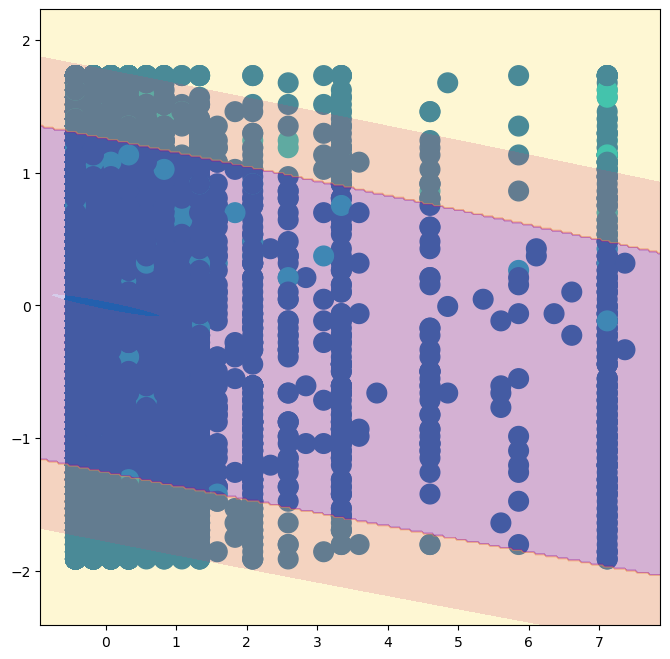

In [12]:
svm_poly = SVC(kernel = "poly",
                C = 1,
                degree = 2, class_weight = 'balanced');
svm_poly.fit(X_train_scaled_bp, y_train_bp)
fig, ax = subplots(figsize = (8, 8))

# Not sure why this one throws an error, the other ones didn't when I reset the index. 
# Still outputs a plot though
plot_svm(X_train_scaled_bp, y_train_bp, svm_poly, scatter_cmap = cm.tab10, ax = ax)

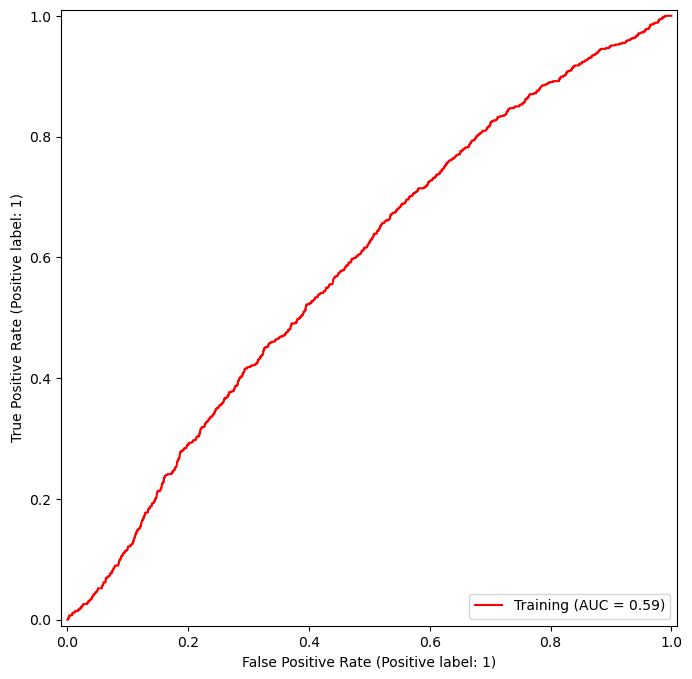

In [16]:
fig, ax = subplots(figsize = (8, 8))
roc_curve(svm_poly,
          X_train_scaled_bp,
          y_train_bp,
          name = 'Training',
          color = 'r',
          ax = ax);

In [37]:
y_hat_test_bp = svm_poly.predict(X_test_scaled_bp)
confusion_table(y_hat_test_bp, y_test_bp)

Truth,0,1
Predicted,,
0,3467,120
1,1201,72


In [20]:
kfold = skm.KFold(2, 
                  random_state = 0,
                  shuffle = True)
grid = skm.GridSearchCV(svm_poly,
                        {'C':[0.01],
                         'degree':[3, 5]},
                        refit = True,
                        cv = kfold,
                        scoring = 'recall');
grid.fit(X_train_scaled_bp, y_train_bp)
grid.best_params_

{'C': 0.01, 'degree': 3}

KeyError: '[29, 30, 31, 34, 35, 44, 46, 52, 54, 59, 75, 101, 115, 119, 127, 133, 134, 139, 147, 150, 167, 168, 175, 180, 194, 200, 208, 210, 217, 218, 221, 224, 230, 239, 245, 247, 251, 257, 259, 263, 265, 274, 278, 280, 290, 308, 311, 313, 315, 322, 323, 326, 327, 334, 335, 341, 344, 345, 346, 351, 359, 360, 367, 380, 383, 397, 408, 409, 410, 423, 424, 428, 438, 447, 451, 457, 459, 466, 474, 478, 482, 484, 491, 499, 501, 509, 512, 513, 516, 520, 536, 538, 547, 554, 563, 575, 584, 585, 586, 606, 610, 616, 618, 624, 631, 635, 638, 643, 655, 668, 673, 674, 681, 688, 695, 697, 715, 718, 720, 725, 733, 735, 738, 744, 748, 752, 776, 790, 803, 809, 812, 819, 826, 828, 829, 833, 843, 852, 856, 866, 875, 878, 880, 905, 911, 913, 943, 945, 960, 962, 964, 970, 980, 984, 996, 1006, 1009, 1012, 1020, 1027, 1035, 1045, 1052, 1056, 1061, 1063, 1065, 1077, 1084, 1087, 1092, 1097, 1108, 1113, 1114, 1121, 1122, 1144, 1147, 1158, 1163, 1166, 1174, 1182, 1187, 1190, 1197, 1199, 1201, 1202, 1205, 1206, 12

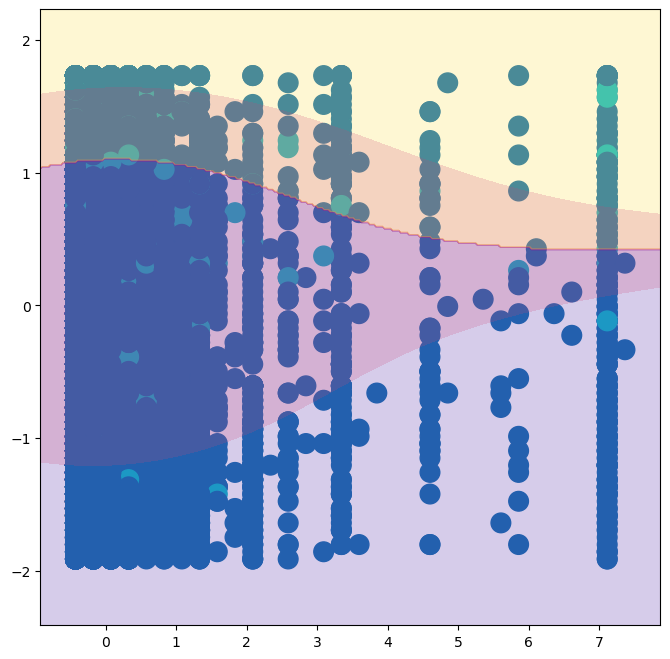

In [24]:
svm_poly2 = SVC(kernel = "poly",
                C = 0.01,
                degree = 3, class_weight = 'balanced');
svm_poly2.fit(X_train_scaled_bp, y_train_bp)
fig, ax = subplots(figsize = (8, 8))
plot_svm(X_train_scaled_bp, y_train_bp, svm_poly2, scatter_cmap = cm.tab10, ax = ax)

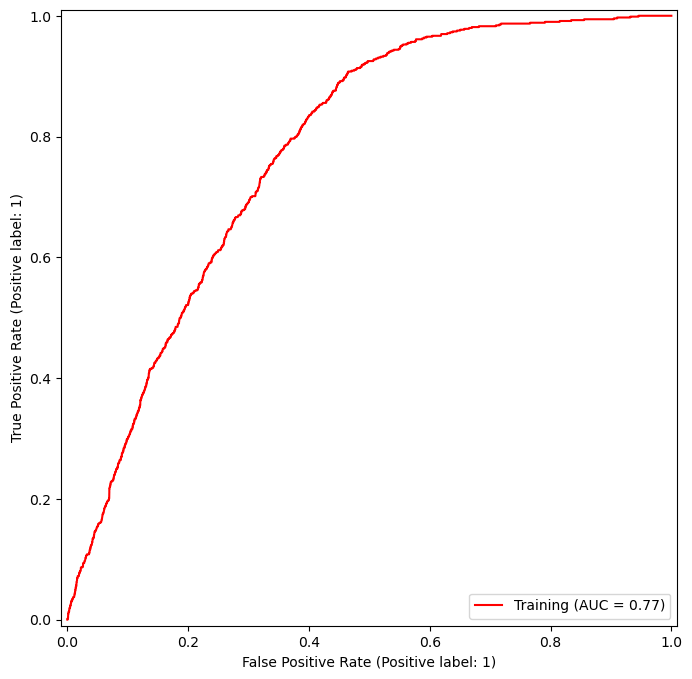

In [26]:
fig, ax = subplots(figsize = (8, 8))
roc_curve(svm_poly2,
          X_train_scaled_bp,
          y_train_bp,
          name = 'Training',
          color = 'r',
          ax = ax);

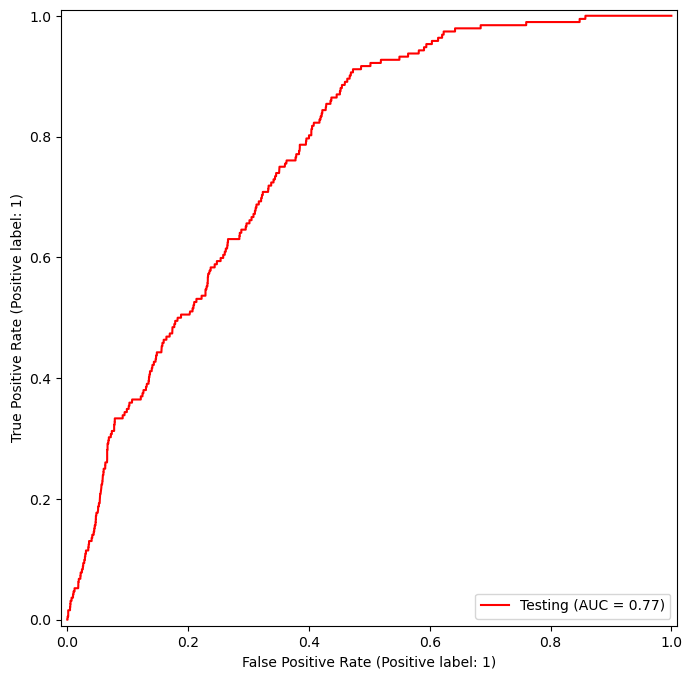

In [27]:
fig, ax = subplots(figsize = (8, 8))
roc_curve(svm_poly2,
          X_test_scaled_bp,
          y_test_bp,
          name = 'Testing',
          color = 'r',
          ax = ax);

AUC of 77 is pretty good for a testing and training score, it shows that there is a decent predictive power for the model

In [39]:
y_hat_test_bp = svm_poly2.predict(X_test_scaled_bp)
confusion_table(y_hat_test_bp, y_test_bp)

Truth,0,1
Predicted,,
0,3670,90
1,998,102


Looking at this report and the confusion matrix above, it looks like we're actually getting some good splits ! Not amazing on the positive size, still only getting around 50% right but that's much better than simply predicting all 0s or all 1s

In [33]:
y_pred = svm_poly2.predict(X_test_scaled_bp)
print(classification_report(y_test_bp, y_pred, 
                           target_names = ['No Heart Attack', 'Heart Attack']))

                 precision    recall  f1-score   support

No Heart Attack       0.98      0.79      0.87      4668
   Heart Attack       0.09      0.53      0.16       192

       accuracy                           0.78      4860
      macro avg       0.53      0.66      0.51      4860
   weighted avg       0.94      0.78      0.84      4860



Solid recall overall, 80% for 0s and 53% for 1s ! After all the fiddling I did on this project, those numbers are the best so far and felt really nice to see